# traQmania 05 — Real quantum hardware

So far every expectation value was computed *exactly* on a statevector
simulator. Real quantum processors give you neither exactness nor speed: you
get **shot noise** (finite samples of a probability distribution), **device
noise** (decoherence, gate errors, readout errors), and **latency** (job
scheduling, queues). This notebook walks the trained driver down that ladder
and reports what holds and what breaks on the way:

1. **The device** — which processor the simulated device imitates, and what
   a simulation of it leaves out.
2. **The circuit on the device** — what transpilation does to the CZ ring.
3. **Running it** — Estimator jobs, execution modes, error mitigation.
4. **What noise does to the driver** — to expectation values, to action
   choices, to laps.
5. **Training for the device** — where a driver's margin comes from: the
   recipe the bundled driver was trained with, next to the same training
   without it.
6. **Mitigation at inference time** — what more shots, a rescale and TREX
   buy, and what they cost.
7. **Why training stays on the simulator.**
8. **The hardware sprint** — the one thing that can be adjusted on
   hardware, with SPSA.

## The backend taxonomy

| backend | what it is | exact? | noise |
|---|---|---|---|
| `fastsim` | numpy statevector + adjoint gradients | yes | none |
| `aer_statevector` | Qiskit Aer through `EstimatorQNN`, precision 0 | yes | none |
| `aer_shots` | Aer with shot sampling | no | shot noise |
| `aer_noisy` | Aer twin of a *fake device* (default `fake_miami`) | no | shots, gate and readout errors, relaxation |
| simulated device | `traqmania.hardware` on an Aer twin of that same fake device, through the Estimator of `qiskit-ibm-runtime` | no | the same |
| real hardware | an IBM Quantum processor, same code path | no | the real thing, plus a queue |

Everything except the last row runs locally and needs no account. The cells
that talk to the (simulated) device need `qiskit-ibm-runtime`; they are
skipped when it is missing or when `TRAQMANIA_SKIP_HW=1` is set (CI does
that), and the real-hardware cell at the end only runs with an IBM Quantum
token.

**How to read this notebook.** The bundled weights are retrained from time
to time, so the prose quotes no measured numbers: every number is computed
and printed by a cell, and a recap cell at the end collects them. Counts
over a handful of episodes or seeds are small samples; every table says how
many. "Device" always means the *simulated* device of section 1.

Run with the hardware cells, this version took 43 and 77 minutes in two runs
on a heavily loaded laptop, nearly all of it simulating the device; with
`TRAQMANIA_SKIP_HW=1` it is a few minutes of training. The timings the cells
print (per job, per update) move with such load by a factor of a few. The
counts do not: the simulator is seeded, and the two runs agreed on every one
of them.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import copy
import importlib.util
import json
import os
import tempfile
import textwrap
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import traqmania
from traqmania.agents.base import action_labels
from traqmania.agents.quantum import QuantumQFunction, lightcone, noise
from traqmania.config import load_config
from traqmania.env.racing_env import RacingEnv
from traqmania.env.track import Track
from traqmania.server.runtime import with_weights_config

# CI sets this to skip the (fake-)hardware cells; harmless when unset.
SKIP_HW = os.environ.get("TRAQMANIA_SKIP_HW") == "1"
# The hardware path needs qiskit-ibm-runtime: pip install "traqmania[hardware]".
HAS_HW = importlib.util.find_spec("qiskit_ibm_runtime") is not None
RUN_HW = HAS_HW and not SKIP_HW


def skipped(what):
    why = "TRAQMANIA_SKIP_HW=1" if SKIP_HW else "qiskit-ibm-runtime is not installed"
    print(f"[skipped ({why}): {what}]")


TRACK = "oval"
WEIGHTS = Path(traqmania.__file__).parent / "weights" / f"quantum_{TRACK}.npz"
# A weights file brings its circuit shape (depth, action count) and its observation
# along in its sidecar: the config follows the file, so a re-bundled driver of
# another depth still loads.
config = with_weights_config(load_config(), WEIGHTS)
track = Track.load(TRACK, config["track"]["resample_spacing"])
params = np.load(WEIGHTS)["params"]
fast = QuantumQFunction(config["circuit"])  # the exact simulator: the reference for everything
fast.set_params(params)
N_QUBITS, N_LAYERS, N_ACTIONS = fast.n_qubits, fast.n_layers, fast.n_actions
ACTIONS = action_labels(N_ACTIONS)

SHOTS = int(config["hardware"]["shots"])  # shots per decision
# Spawn jitter of the evaluation episodes: an env seed that no training run, no study
# evaluation and no driver selection used (the studies rank their seeds on 20000, the
# bundling tool re-checks on 31000, a trainer with seed s evaluates on s + 10000).
EVAL_SEED = 41_000
# Attenuation assumed where no device calibration is available (hardware cells skipped).
NOMINAL_ATTENUATION = 0.95
RECAP = []  # (topic, text) lines collected for the recap at the end

print(f"driver: {WEIGHTS.name}  ({N_QUBITS} qubits, {N_LAYERS} blocks, {fast.n_params} "
      f"parameters, actions {', '.join(ACTIONS)})")
print(f"shots per decision: {SHOTS}")
if not RUN_HW:
    skipped("every cell that runs on the simulated device")

driver: quantum_oval.npz  (4 qubits, 4 blocks, 56 parameters, actions Right, Straight, Left, Brake)
shots per decision: 1024


### The driver

The driver under test is the bundled 4-qubit oval driver, the one the game
loads by default. It is **not a neutral test subject**: it was trained with
a recipe aimed at device noise (section 5 takes that recipe apart) and then
*chosen* among several training seeds, with laps on this very simulated
device as the first criterion. Its sidecar file records all of that, and
the next cell prints it. So when it laps under noise below, that confirms a
selection on other episodes; it is not a discovery. Where the robustness
comes from, and what a driver without it looks like, is the subject of
sections 5 and 6.

In [2]:
def sidecar(path):
    """The .meta.json next to a weights file ({} when there is none)."""
    meta = Path(path).with_suffix("").with_suffix(".meta.json")
    return json.loads(meta.read_text(encoding="utf-8")) if meta.is_file() else {}


def interval(stat, fmt="{:.2f}"):
    """'IQM [low, high]' of one seed-spread entry of a sidecar."""
    low, high = fmt.format(stat["ci_low"]), fmt.format(stat["ci_high"])
    return f"{fmt.format(stat['iqm'])} [{low}, {high}]"


META = sidecar(WEIGHTS)
recipe, selection = META.get("training", {}), META.get("selection", {})
print(f"{WEIGHTS.name}: trained {META.get('date', '?')} on the exact simulator, "
      f"{recipe.get('episodes', '?')} episodes, seed {recipe.get('seed', '?')}")
print("  recipe: " + ", ".join(f"{key} = {recipe[key]}" for key in
                               ("bootstrap_truncation", "action_gap", "act_noise")
                               if key in recipe))
if selection:
    print(f"  one of {selection['n_seeds']} seeds trained this way (study "
          f"'{selection['study']}', variant '{selection['variant']}')")
    print(textwrap.fill("how it was chosen: " + selection["rule"], width=96,
                        initial_indent="  ", subsequent_indent="    "))
    print(f"\n  {'candidate':<12}{'study eval':>12}{'fresh episodes':>16}{'mean lap':>10}"
          f"{'simulated device':>18}")
    for c in selection.get("candidates", []):
        on_device = (f"{c['device_lapped']}/{c['device_episodes']}"
                     if "device_lapped" in c else "-")
        print(f"  {'seed ' + str(c['seed']):<12}"
              f"{c['study_lapped']:>9}/{c['study_episodes']}"
              f"{c['fresh_lapped']:>13}/{c['fresh_episodes']}{c['fresh_mean_lap']:>8.1f} s"
              f"{on_device:>18}"
              + ("   <- bundled" if c["seed"] == selection["chosen_seed"] else ""))
    check = selection.get("device_eval")
    if check:
        print(f"  device check: {check['backend']}, {check['shots']} shots, rescale "
              f"{check['rescale']}, resilience {check['resilience']}, at most "
              f"{check['max_decisions']} decisions per episode")
        RECAP.append(("driver", f"{WEIGHTS.name}: seed {selection['chosen_seed']} of "
                      f"{selection['n_seeds']}; at selection {check['lapped']}/"
                      f"{check['episodes']} episodes lapped on {check['fake']}"))
    spread = selection.get("seed_spread")
    if spread:
        print(f"\n  the recipe over all {spread['n_seeds']} seeds, exact simulator "
              f"(IQM [95% CI] of the lapped fraction):")
        print(f"    best snapshot {interval(spread['best_snapshot_lapped'])}, final "
              f"parameters {interval(spread['final_params_lapped'])}, stability "
              f"{interval(spread['stability'])}")
else:
    print("  (the sidecar records no selection)")

quantum_oval.npz: trained 2026-10-02 on the exact simulator, 800 episodes, seed 0
  recipe: bootstrap_truncation = True, action_gap = 0.8, act_noise = {'attenuation': 0.95, 'shots': 1024}
  one of 10 seeds trained this way (study 'robust_oval', variant 'gap8an')
  how it was chosen: seeds ranked by the study's 36-episode reliability eval of the best
    snapshot (lapped fraction, then mean lap); the top 4 re-evaluated on 72 fresh distinct
    greedy episodes (env seed 31000) and the driver chosen by that result (episodes lapped on
    the simulated device, then lapped fraction, then mean lap); the fresh numbers are the ones
    recorded (they also picked among the 4 candidates, so a small selection effect remains in
    them)

  candidate     study eval  fresh episodes  mean lap  simulated device
  seed 0             36/36           72/72    12.7 s               8/8   <- bundled
  seed 1             36/36           72/72    12.8 s               8/8
  seed 4             36/36           

## 1. The device

`traqmania.hardware.get_backend(use_fake=True)` returns a **fake backend**
from `qiskit-ibm-runtime`: a frozen calibration snapshot of one IBM
processor — its coupling map, its native gates, the error of every gate and
every readout, T1 and T2 — which Aer turns into a noise model and simulates
locally. The default is `fake_miami`, a snapshot of a **Nighthawk**
processor: CZ as the two-qubit gate, qubits on a **square lattice** (the
cell prints its size).

Three devices are worth telling apart:

- **`fake_miami`** (default) — the current generation, square lattice. The
  next section shows why that lattice suits this circuit.
- **`fake_fez`** and the other Herons — also current and CZ-based, but on a
  *heavy-hex* lattice, where a qubit has at most three neighbours. (Which
  processors an account can use depends on its plan.)
- **`fake_manila`** and the other small `...V2` fakes — *Falcon* devices
  with CX gates and a handful of qubits. They are retired; an earlier
  version of this notebook ran on one. They stay available by name
  (`fake_name="fake_manila"`), but say little about what a job meets today.

(`docs/SCIENCE.md`, section "Hardware", has the sources for the fleet and
the plans.)

**A fake device is not a QPU.** What the simulation has: the snapshot's
gate, readout and relaxation errors on the qubits the circuit uses, and real
shot sampling. What it lacks: a queue, calibration drift between jobs,
crosstalk and leakage, and anything else a noise model built from average
error rates does not contain. Results on the fake are a *preview* of a real
run, not a prediction of one: IBM's
[fake-provider documentation](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider)
itself warns that the snapshots were taken in the past and are not
representative of the latest behaviour of the systems they mimic. And the
noise model of a whole processor of that size is far too big to simulate per
decision, so `traqmania.hardware` routes the circuit onto the full device once
and simulates only the physical qubits it lands on — a **device patch** with
those qubits' own errors and couplings.

In [3]:
if RUN_HW:
    from traqmania import hardware

    FAKE = config["hardware"].get("fake_name") or hardware.DEFAULT_FAKE
    device = hardware.get_backend(use_fake=True, fake_name=FAKE)

    def facts(backend):
        """Lattice and calibration facts of a backend, read from its Target."""
        target = backend.target
        gate = next(name for name in ("cz", "ecr", "cx") if name in target.operation_names)
        couplers = {tuple(sorted(pair)) for pair in backend.coupling_map.get_edges()}
        neighbours = np.bincount(np.array(sorted(couplers)).ravel(),
                                 minlength=backend.num_qubits)

        def median_error(name):
            return np.median([p.error for p in target[name].values()
                              if p is not None and p.error is not None])

        family = (getattr(backend, "processor_type", None) or {}).get("family", "?")
        return (f"{backend.name:<13}{family:<11}{backend.num_qubits:>6}{len(couplers):>10}"
                f"{neighbours.max():>12}{gate:>9}{median_error(gate):>12.4f}"
                f"{median_error('measure'):>12.4f}")

    COMPARE = list(dict.fromkeys([device.name, "fake_fez", "fake_manila"]))
    DEVICES = {name: (device if name == device.name
                      else hardware.get_backend(use_fake=True, fake_name=name))
               for name in COMPARE}
    print(f"{'device':<13}{'family':<11}{'qubits':>6}{'couplers':>10}{'neighbours':>12}"
          f"{'2q gate':>9}{'2q error':>12}{'readout':>12}   (errors: device medians)")
    for backend in DEVICES.values():
        print(facts(backend))

    # What actually gets simulated for the default device: a patch of it.
    twin = hardware.execution_backend(device, config["circuit"])
    print(f"\nsimulated locally as: {hardware.backend_label(twin)}")
else:
    skipped("device facts")

device       family     qubits  couplers  neighbours  2q gate    2q error     readout   (errors: device medians)
fake_miami   Nighthawk     120       218           4       cz      0.0030      0.0179
fake_fez     Heron         156       176           3       cz      0.0039      0.0076
fake_manila  Falcon          5         4           2       cx      0.0101      0.0219

simulated locally as: fake_miami (4-qubit patch: physical qubits 4, 5, 14, 15)


## 2. The circuit on the device

A device runs only its native gates on its own couplers, so the circuit from
[notebook 03](03_quantum_circuits_as_q_functions.ipynb) is **transpiled** to
the device's instruction set (an *ISA circuit*): single-qubit rotations
become `rz`/`sx`, and every CZ between qubits that are not neighbours on the
chip has to be **routed** with SWAPs — three two-qubit gates each before the
optimizer merges what it can. Every two-qubit gate adds error and depth
(and with depth, time for the qubits to relax), and they are what routing
multiplies, so their count is the number to watch.

Two things keep it low here:

- **The lattice.** The entangler is a ring of CZs. A ring on an even number
  of qubits is the perimeter of a 2 × n/2 rectangle, which a square lattice
  contains — no routing needed. Heavy-hex has no cycle that short, and a
  line of five qubits has no cycle at all.
- **Light-cone pruning.** [Notebook 07](07_light_cones_and_classical_surrogates.ipynb)
  shows that some gates cannot influence any readout (the last CZ ring never
  does). `traqmania.hardware` leaves them out by default: the expectation
  values are mathematically identical, and the device executes fewer gates.

The cell transpiles the full and the pruned circuit for each device with
Qiskit's preset pass manager, best of a few layout seeds (routing is
stochastic) — the same thing `traqmania.hardware` does internally. To count
SWAPs it routes once more on the same coupling map with SWAP allowed as a
gate, so the router's SWAPs stay visible instead of being decomposed.

In [4]:
if RUN_HW:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    from traqmania.agents.quantum.circuit import build_circuit

    LAYOUT_SEEDS = range(8)

    def two_qubit_gates(circuit):
        return sum(inst.operation.num_qubits == 2 for inst in circuit.data)

    def to_isa(circuit, backend):
        """(ISA circuit, layout seed) with the fewest two-qubit gates, then lowest depth."""
        best = None
        for seed in LAYOUT_SEEDS:
            isa = generate_preset_pass_manager(
                optimization_level=2, backend=backend, seed_transpiler=seed).run(circuit)
            cost = (two_qubit_gates(isa), isa.depth())
            if best is None or cost < best[0]:
                best = (cost, isa, seed)
            if cost[0] <= two_qubit_gates(circuit):  # nothing was added: no routing needed
                break
        return best[1], best[2]

    def swaps(circuit, backend, seed):
        """SWAPs the router inserts for this layout seed (SWAP kept as a basis gate)."""
        basis = [name for name in backend.target.operation_names
                 if name in ("rz", "sx", "x", "cz", "cx", "ecr")] + ["swap"]
        routed = generate_preset_pass_manager(
            optimization_level=2, coupling_map=backend.coupling_map, basis_gates=basis,
            seed_transpiler=seed).run(circuit)
        return routed.count_ops().get("swap", 0)

    def variants(n_qubits, n_layers, n_actions=None):
        return {"full": build_circuit(n_qubits, n_layers),
                "pruned": lightcone.pruned_circuit(n_qubits, n_layers, n_actions).circuit}

    print(f"{N_QUBITS}-qubit circuit, {N_LAYERS} blocks")
    print(f"{'device':<13}{'circuit':<9}{'CZ in circuit':>14}{'2q gates on device':>20}"
          f"{'SWAPs':>7}{'depth':>7}")
    ISA = {}
    for name, backend in DEVICES.items():
        for label, circuit in variants(N_QUBITS, N_LAYERS, N_ACTIONS).items():
            isa, seed = to_isa(circuit, backend)
            ISA[name, label] = isa
            n_swaps = swaps(circuit, backend, seed)
            print(f"{name:<13}{label:<9}{two_qubit_gates(circuit):>14}"
                  f"{two_qubit_gates(isa):>20}{n_swaps:>7}{isa.depth():>7}")
            if name == device.name:
                RECAP.append(("circuit", f"{label} circuit on {name}: {two_qubit_gates(isa)} "
                              f"two-qubit gates, {n_swaps} SWAPs, depth {isa.depth()}"))

    # Where the pruned circuit sits on the default device, and how good those qubits are.
    isa = ISA[device.name, "pruned"]
    physical = isa.layout.initial_index_layout(filter_ancillas=True)
    print(f"\non {device.name} circuit qubits 0..{N_QUBITS - 1} sit on physical qubits {physical}")
    gate = next(name for name in ("cz", "ecr", "cx") if name in device.target.operation_names)
    errors = device.target[gate]
    ring = [(physical[i], physical[(i + 1) % N_QUBITS]) for i in range(N_QUBITS)]
    ring_errors = [(errors.get(pair) or errors.get(pair[::-1])) for pair in ring
                   if pair in errors or pair[::-1] in errors]
    print(f"  ring CZs that are couplers of the chip: {len(ring_errors)} of {len(ring)}; "
          f"their {gate} errors: " + ", ".join(f"{p.error:.4f}" for p in ring_errors))
    print("  readout errors of the action qubits: " + ", ".join(
        f"{device.target['measure'][(q,)].error:.4f}" for q in physical[:N_ACTIONS]))

    # The same ring at the larger profiles (each profile's own circuit shape).
    current = [name for name in DEVICES if name != "fake_manila"]
    print("\ntwo-qubit gates on device (SWAPs), full / pruned circuit")
    print(f"{'profile':<9}{'qubits':>7}{'blocks':>7}" + "".join(f"{name:>26}" for name in current))
    for profile in ("q6", "q8", "q10"):
        shape = load_config(profile)["circuit"]
        n, layers = int(shape["n_qubits"]), int(shape["n_layers"])
        cells = []
        for name in current:
            parts = []
            for circuit in variants(n, layers, shape.get("n_actions")).values():
                isa, seed = to_isa(circuit, DEVICES[name])
                parts.append(f"{two_qubit_gates(isa)} ({swaps(circuit, DEVICES[name], seed)})")
            cells.append(" / ".join(parts))
        print(f"{profile:<9}{n:>7}{layers:>7}" + "".join(f"{cell:>26}" for cell in cells))
else:
    skipped("transpilation facts")

4-qubit circuit, 4 blocks
device       circuit   CZ in circuit  2q gates on device  SWAPs  depth


fake_miami   full                 16                  16      0     44
fake_miami   pruned               12                  12      0     39


fake_fez     full                 16                  37      7    107


fake_fez     pruned               12                  27      5     85


fake_manila  full                 16                  50     14    116


fake_manila  pruned               12                  38     10     95

on fake_miami circuit qubits 0..3 sit on physical qubits [14, 4, 5, 15]
  ring CZs that are couplers of the chip: 4 of 4; their cz errors: 0.0036, 0.0015, 0.0019, 0.0029
  readout errors of the action qubits: 0.0088, 0.0140, 0.0171, 0.0071

two-qubit gates on device (SWAPs), full / pruned circuit
profile   qubits blocks                fake_miami                  fake_fez


q6             6      4           24 (0) / 17 (0)         74 (18) / 47 (12)


q8             8      5           40 (0) / 28 (0)         100 (20) / 52 (8)


q10           10      4           40 (0) / 21 (0)           64 (8) / 21 (0)


Read the first table row by row: where "2q gates on device" equals "CZ in
circuit" and the SWAP column is zero, the ring fits the chip as it is; every
SWAP elsewhere is paid for in extra two-qubit gates and depth. The pruned
rows show what leaving out the dead gates saves on top of that. The last
table repeats the count for the wider profiles, each at the number of blocks
its profile (`traqmania/config/q*.toml`) currently sets — the `blocks` column
follows the profile when that changes. (A pruned circuit that is too shallow
for its width is no longer a full ring — notebook 07 explains why — and can
then be easier to route than the full one.)

## 3. Running it: jobs, modes, mitigation

**One decision = one job.** `HardwareQFunction` speaks the same `QFunction`
protocol as the simulator, but each `q_values` call submits one *Estimator*
job: the ISA circuit, the four observables $Z_0 \dots Z_3$, and one row of
parameter values per car. The job returns $\langle Z_a \rangle$ estimated
from a finite number of shots, and the classical head turns them into
Q-values, $Q_a = w_a \langle Z_a \rangle + b_a$.

**The Estimator.** Current `qiskit-ibm-runtime` ships a *client-side*
Estimator (`qiskit_ibm_runtime.executor_estimator.Estimator`): circuit
preparation and error-mitigation post-processing run on your machine, and
the device only executes circuits. `traqmania.hardware` uses it and falls
back to the older server-side `EstimatorV2` on runtimes that do not have it.

**Execution modes.** IBM Quantum offers three: a **Session** (dedicated
access to the QPU while it is open — what a closed loop of hundreds of
small jobs wants), a **Batch** (jobs scheduled together) and plain **job**
mode (every job queues on its own). The free **Open Plan cannot open
Sessions** ([IBM's guide](https://quantum.cloud.ibm.com/docs/en/guides/choose-execution-mode)),
so `traqmania.hardware` asks for a Session, falls back to a Batch and then
to job mode, and reports which one it got and why. On a real device without
a Session each decision waits in the queue again, which turns a lap into a
very long experiment. The local twin grants a Session (a local testing
mode: nothing is queued).

**Error mitigation** is chosen with the Estimator's `resilience_level`
([IBM's guide](https://quantum.cloud.ibm.com/docs/en/guides/estimator-noise-management)):
0 applies none, 1 adds TREX readout-error mitigation, 2 adds zero-noise
extrapolation with gate twirling on top. The runtime's own default is 1;
`traqmania.hardware` defaults to **0**, so that what you see first is the
raw device. traQmania adds one mitigation of its own, `rescale`: one extra
calibration job compares the device with the exact simulator on random
inputs and every later readout is corrected for the fitted attenuation.
Both are put to work in section 6.

The cell opens an execution mode on the local twin, builds the driver on the
device, and makes the same decision five times.

In [5]:
if RUN_HW:
    import qiskit_ibm_runtime

    try:
        from qiskit_ibm_runtime.executor_estimator import Estimator
    except ImportError:  # older runtime: only the server-side primitive exists
        from qiskit_ibm_runtime import EstimatorV2 as Estimator
    print(f"qiskit-ibm-runtime {qiskit_ibm_runtime.__version__}; Estimator: "
          f"{Estimator.__module__}.{Estimator.__name__}")
    for level, text in hardware.RESILIENCE_LEVELS.items():
        print(f"  resilience_level {level}: {text}")

    mode, mode_name, note = hardware.open_execution_mode(twin)
    print(f"\nexecution mode granted by the local twin: {mode_name}"
          + (f"  (note: {note})" if note else ""))
    if mode is not None:
        mode.close()

    def device_qfunction(weights, shots=SHOTS, resilience_level=0, rescale=None, seed=0):
        """A driver on the simulated device: every q_values call is one Estimator job."""
        hw = hardware.HardwareQFunction(config["circuit"], device, shots=shots,
                                        resilience_level=resilience_level, rescale=rescale)
        hw.set_params(weights)
        hw.seed_simulator(seed)  # reproducible shot noise; a real device ignores this
        return hw

    hw = device_qfunction(params)
    print(f"circuit as run: {hw.two_qubit_gates} two-qubit gates, depth {hw.depth}, "
          f"on {hw.backend_name}")

    obs = RacingEnv(track, config, n_envs=1, seed=EVAL_SEED).reset()
    q_exact = fast.q_values(obs)[0]
    print(f"\nthe first decision of an episode, {SHOTS} shots per job:")
    print(f"  exact   Q = [{', '.join(f'{v:8.2f}' for v in q_exact)}]  -> "
          f"{ACTIONS[int(np.argmax(q_exact))]}")
    for job in range(5):
        t0 = time.perf_counter()
        q = hw.q_values(obs)[0]
        print(f"  job {job + 1}   Q = [{', '.join(f'{v:8.2f}' for v in q)}]  -> "
              f"{ACTIONS[int(np.argmax(q))]:<9} ({1e3 * (time.perf_counter() - t0):.0f} ms)")
else:
    skipped("Estimator, execution mode and a first decision on the device")

qiskit-ibm-runtime 0.50.0; Estimator: qiskit_ibm_runtime.executor_estimator.estimator.Estimator
  resilience_level 0: raw device noise, no error mitigation
  resilience_level 1: TREX readout-error mitigation
  resilience_level 2: TREX + ZNE with gate twirling

execution mode granted by the local twin: session


circuit as run: 12 two-qubit gates, depth 39, on fake_miami (4-qubit patch: physical qubits 4, 5, 14, 15)

the first decision of an episode, 1024 shots per job:
  exact   Q = [   53.95,    74.79,    84.58,    55.11]  -> Left


  job 1   Q = [   53.41,    71.21,    83.29,    52.39]  -> Left      (160 ms)


  job 2   Q = [   54.83,    67.17,    85.29,    49.70]  -> Left      (934 ms)


  job 3   Q = [   53.15,    74.54,    83.69,    55.34]  -> Left      (302 ms)
  job 4   Q = [   53.67,    71.33,    83.83,    52.39]  -> Left      (184 ms)


  job 5   Q = [   52.64,    71.45,    81.03,    54.19]  -> Left      (366 ms)


## 4. What device noise does to the driver

### 4.1 To the expectation values

The policy only ever looks at four numbers, $\langle Z_0\rangle \dots
\langle Z_3\rangle$. To a good approximation a noisy device does three
things to each of them:

$$\langle Z_a\rangle_\text{device} \;\approx\; f_a\,\langle Z_a\rangle_\text{exact} \;+\; \beta_a \;+\; \text{shot noise},
\qquad \sigma_\text{shot} = \sqrt{\frac{1-\langle Z_a\rangle^2}{\text{shots}}}$$

- an **attenuation** $f_a < 1$: gate and readout errors shrink every
  expectation value toward zero;
- a small **bias** $\beta_a$ (asymmetric readout error, relaxation);
- **shot noise**, which more shots reduce and nothing else does.

The cell measures this: 64 random inputs through the device at many shots,
compared with the exact simulator (`noise.fit_attenuation` does the
least-squares fit) — once raw, once with TREX. The `rescale` mitigation
runs the same kind of calibration job. The fitted slopes and
biases at resilience 0 become the **emulation model** used below: fastsim
plus this noise is a cheap stand-in for the device, good enough to compare
many episodes, not a replacement for running on it.

resilience 0 (raw device noise, no error mitigation), 16384 shots:
  one attenuation for all readouts: f = 0.949   (rms error of <Z>: 0.0285)
  per readout: slope 0.949 0.947 0.960 0.937   bias -0.0008 -0.0011 -0.0019 +0.0010
  left over after the per-readout fit: 0.0074 rms (shot noise alone would leave 0.0067)


resilience 1 (TREX readout-error mitigation), 16384 shots:
  one attenuation for all readouts: f = 0.975   (rms error of <Z>: 0.0160)
  per readout: slope 0.978 0.981 0.974 0.955   bias +0.0010 -0.0002 -0.0022 +0.0011
  left over after the per-readout fit: 0.0077 rms (shot noise alone would leave 0.0067)


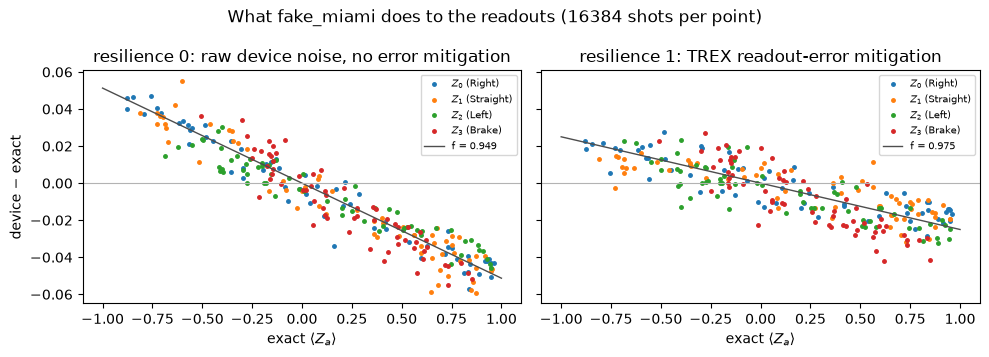

emulation model, fitted to fake_miami: attenuation [0.949, 0.947, 0.960, 0.937], 1024 shots, bias [-0.001, -0.001, -0.002, 0.001]


In [6]:
if RUN_HW:
    CAL_SHOTS = 16 * SHOTS
    cal_obs = noise.calibration_inputs(fast.n_features, 64, seed=0)
    z_exact = fast.expectations(cal_obs)
    FITS, measured = {}, {}
    for level in (0, 1):
        hw = device_qfunction(params, shots=CAL_SHOTS, resilience_level=level, seed=10 + level)
        measured[level] = hw.expectations(cal_obs)  # one job: 64 inputs x 4 observables
        FITS[level] = fit = noise.fit_attenuation(measured[level], z_exact, shots=CAL_SHOTS)
        print(f"resilience {level} ({hardware.RESILIENCE_LEVELS[level]}), {CAL_SHOTS} shots:")
        print(f"  one attenuation for all readouts: f = {fit['attenuation']:.3f}   "
              f"(rms error of <Z>: {fit['rms_error']:.4f})")
        print("  per readout: slope " + " ".join(f"{v:.3f}" for v in fit["slope_per_readout"])
              + "   bias " + " ".join(f"{v:+.4f}" for v in fit["bias_per_readout"]))
        print(f"  left over after the per-readout fit: {fit['affine_residual_rms']:.4f} rms "
              f"(shot noise alone would leave {fit['shot_rms']:.4f})")
    fit = FITS[0]
    DEVICE_MODEL = noise.ExpectationNoise(attenuation=tuple(fit["slope_per_readout"]),
                                          bias=tuple(fit["bias_per_readout"]), shots=SHOTS)
    MODEL_SOURCE = f"fitted to {device.name}"
    RECAP.append(("noise", f"attenuation on {device.name}: f = {fit['attenuation']:.3f} raw, "
                  f"{FITS[1]['attenuation']:.3f} with TREX; per-readout slopes "
                  f"{min(fit['slope_per_readout']):.3f}-{max(fit['slope_per_readout']):.3f}"))

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
    for ax, level in zip(axes, (0, 1), strict=True):
        for a in range(N_ACTIONS):
            ax.plot(z_exact[:, a], measured[level][:, a] - z_exact[:, a], ".", ms=5,
                    label=f"$Z_{a}$ ({ACTIONS[a]})")
        x = np.array([-1.0, 1.0])
        ax.plot(x, (FITS[level]["attenuation"] - 1.0) * x, color="0.3", lw=1,
                label=f"f = {FITS[level]['attenuation']:.3f}")
        ax.axhline(0.0, color="0.7", lw=0.8)
        ax.set(xlabel=r"exact $\langle Z_a\rangle$",
               title=f"resilience {level}: {hardware.RESILIENCE_LEVELS[level]}")
        ax.legend(fontsize=7)
    axes[0].set_ylabel(r"device $-$ exact")
    fig.suptitle(f"What {device.name} does to the readouts ({CAL_SHOTS} shots per point)")
    plt.tight_layout()
    plt.show()
else:
    # No device to calibrate against: a plain nominal attenuation, no bias.
    DEVICE_MODEL = noise.ExpectationNoise(attenuation=NOMINAL_ATTENUATION, shots=SHOTS)
    MODEL_SOURCE = "nominal (no device calibration)"
    skipped("device calibration")
print(f"emulation model, {MODEL_SOURCE}: {DEVICE_MODEL.describe()}")

### 4.2 To the action choices

The errors the last cell printed look small. But the output head multiplies
them by $|w_a|$ (the next cell prints how large this driver's head is), and
the policy acts on an argmax. What decides whether the car still
turns the right way is the **gap between the best and the second-best
Q-value** compared with the noise on that gap. Two different things can
close it:

- **shot noise** — random, a different draw at every decision;
- **unequal attenuation** — systematic. Shrinking all four readouts by the
  same factor mostly preserves their ranking (it only shifts the balance
  between $w_a\langle Z_a\rangle$ and the bias $b_a$); shrinking them by
  *different* factors re-ranks actions directly, and no number of shots
  repairs that.

The next cell needs no hardware: it takes every state the driver visits in
four greedy episodes on the exact simulator and expresses each top-2 gap in
units of the shot noise on it (treating the shot noise of the two readouts as independent, as the
emulation does; on a device all readouts come from the same shots). These
are the numbers the training recipe of section 5 is meant to move, so keep
them in mind until the table there.

In [7]:
MARGIN_STATES = 10_000  # more than four greedy episodes visit, i.e. every state of theirs


def margins(qf, shots=SHOTS, states=MARGIN_STATES):
    """Top-2 Q-value gap at the states the driver itself visits (four greedy
    episodes on the exact simulator): in Q units, and in units of the shot-noise
    standard deviation of that gap."""
    obs = noise.trajectory_states(qf, TRACK, config, states, seed=EVAL_SEED)
    z = qf.expectations(obs)
    q = z * qf.w + qf.b
    order = np.argsort(q, axis=1)
    rows, first, second = np.arange(len(q)), order[:, -1], order[:, -2]
    gap = q[rows, first] - q[rows, second]
    variance = qf.w**2 * (1.0 - z**2) / shots
    return gap, gap / np.sqrt(variance[rows, first] + variance[rows, second])


gap, gap_sigma = margins(fast)
print(f"bundled driver, the {len(gap)} states of four greedy episodes on the exact "
      f"simulator:")
print(f"  output head: mean |w| = {np.mean(np.abs(fast.w)):.1f}  ->  one standard deviation "
      f"of shot noise is up to {np.mean(np.abs(fast.w)) / np.sqrt(SHOTS):.2f} Q units "
      f"per action at {SHOTS} shots")
print(f"  top-2 gap: median {np.median(gap):.2f} Q units, 10th percentile "
      f"{np.percentile(gap, 10):.2f}")
print(f"  gap / shot noise: median {np.median(gap_sigma):.2f} sigma; "
      f"{np.mean(gap_sigma < 1):.0%} of the states under 1 sigma, "
      f"{np.mean(gap_sigma < 2):.0%} under 2")
RECAP.append(("noise", f"bundled driver: median top-2 gap {np.median(gap):.2f} Q units = "
              f"{np.median(gap_sigma):.2f} sigma of shot noise at {SHOTS} shots; "
              f"{np.mean(gap_sigma < 1):.0%} of its on-trajectory states under 1 sigma"))

bundled driver, 64 states of its own exact trajectory:
  output head: mean |w| = 65.1  ->  one standard deviation of shot noise is up to 2.04 Q units per action at 1024 shots
  top-2 gap: median 8.17 Q units, 10th percentile 0.97
  gap / shot noise: median 5.11 sigma; 17% of the states under 1 sigma, 27% under 2


A gap of one sigma is a decision the shot noise overturns about one time in
six; a gap of several sigma is safe from it. No driver has wide gaps
everywhere: where two actions are nearly as good as each other the gap is
small by nature, and a flip there costs little. So the share of states under
one sigma says how often decisions *can* flip, not how often it matters.

Now the measurement on the device: a few hundred on-trajectory states of
the same kind, evenly thinned from the episodes and sent through the device
more than once (the cell prints both numbers), counting how often the
device's greedy action differs from the exact one — at the working number of shots, and once at very many
shots, where only the *systematic* flips remain. `noise.validate` also
reports what the two emulation models predict (one attenuation for all
readouts, or a slope and bias per readout), which says how far the cheap
emulation can be trusted for this driver.

In [8]:
FLIP_STATES = 256  # on-trajectory states per device job, evenly thinned from the episodes

if RUN_HW:
    flips = noise.validate(WEIGHTS, TRACK, FAKE, shots=SHOTS, states=FLIP_STATES, repeats=2,
                           seed=0)
    print(f"{flips['states']} on-trajectory states x {flips['repeats']} jobs at "
          f"{flips['shots']} shots on {flips['backend']}")
    print(f"{'action differs from the exact policy':<40}{'at these shots':>15}"
          f"{'systematic':>12}")
    print(f"{'  device':<40}{flips['device_flip_rate']:>11.0%} +-"
          f"{flips['device_flip_stderr']:.0%}{flips['device_systematic_flip_rate']:>11.0%}")
    for key, label in (("per_readout", "  emulation: slope + bias per readout"),
                       ("global", "  emulation: one attenuation")):
        emu = flips["emulation"][key]
        print(f"{label:<40}{emu['flip_rate']:>11.0%}{emu['systematic_flip_rate']:>15.0%}")
    print(f"(systematic: the device at {flips['reference_shots']} shots, the emulation "
          f"without shot noise)")
    RECAP.append(("noise", f"bundled driver on {device.name}: {flips['device_flip_rate']:.0%} "
                  f"of on-trajectory decisions differ from the exact policy at {SHOTS} shots, "
                  f"{flips['device_systematic_flip_rate']:.0%} even at "
                  f"{flips['reference_shots']} shots"))
else:
    skipped("action flips on the device")

64 on-trajectory states x 8 jobs at 1024 shots on fake_miami (4-qubit patch: physical qubits 4, 5, 14, 15)
action differs from the exact policy     at these shots  systematic
  device                                         6% +-1%         5%
  emulation: slope + bias per readout            6%             5%
  emulation: one attenuation                     7%             0%
(systematic: the device at 100000 shots, the emulation without shot noise)


### 4.3 To the laps

A flipped decision is not yet a crash — many flips are between two nearly
equivalent actions, and a driver that leaves a margin where it counts can
afford them. What counts is whether the car still gets round. The yardstick
used from here on:

> An **episode** starts from a standing start (each episode with its own
> small spawn jitter) and ends at the first completed lap, at a crash, or
> after `LAP_CAP` decisions. A driver's score is the number of episodes that
> **lapped**.

Three ways to drive an episode:

- **exact** — fastsim, no noise: what the driver can do at best;
- **emulation** — fastsim plus the noise model fitted above: cheap, so it
  gets many episodes;
- **device** — every decision an Estimator job on the simulated device: the
  number that counts, but slow even as a local simulation (the tables print
  the time per job), so it gets fewer episodes.

In [9]:
EPISODES = 36  # exact / emulated episodes per driver
DEVICE_EPISODES = 8  # episodes per setting on the device (each decision is a job)
LAP_CAP = 250  # decisions allowed for the first lap


def drive(qfunc, episodes, seed=EVAL_SEED):
    """`episodes` greedy episodes side by side, each from its own spawn jitter,
    each ended by its first lap, its crash or LAP_CAP decisions. One q_values
    call per decision, for the cars still driving."""
    env = RacingEnv(track, config, n_envs=episodes, seed=seed)
    obs = env.reset()
    running = np.ones(episodes, dtype=bool)
    lapped = np.zeros(episodes, dtype=bool)
    decisions = np.zeros(episodes, dtype=int)
    paths = [[xy] for xy in env.state[:, :2].copy()]
    for _ in range(LAP_CAP):
        actions = np.zeros(episodes, dtype=int)
        actions[running] = np.argmax(qfunc.q_values(obs[running]), axis=1)
        obs, _reward, done, info = env.step(actions)
        decisions[running] += 1
        lapped |= running & (info["lap"] >= 1)
        running &= ~(done | lapped)
        for i in np.flatnonzero(running):
            paths[i].append(env.state[i, :2].copy())
        if not running.any():
            break
    return {"lapped": lapped, "decisions": decisions,
            "paths": [np.array(path) for path in paths]}


def score(result):
    return f"{int(result['lapped'].sum()):>2}/{result['lapped'].size}"


def emulated(qf, model, seed=0):
    """`qf` behind an expectation-noise model: every q_values call sees fresh noise."""
    return noise.NoisyQFunction(qf, model, rng=seed)


SHOTS_ONLY = noise.ExpectationNoise(shots=SHOTS)
bundled = {
    "exact": drive(fast, EPISODES),
    "shots only": drive(emulated(fast, SHOTS_ONLY, seed=1), EPISODES),
    "emulated": drive(emulated(fast, DEVICE_MODEL, seed=2), EPISODES),
}
print(f"bundled driver on {TRACK}, episodes that lapped (first lap within {LAP_CAP} decisions):")
for label, key in (("exact simulator", "exact"),
                   (f"shot noise only, {SHOTS} shots", "shots only"),
                   (f"emulated device ({MODEL_SOURCE})", "emulated")):
    print(f"  {label:<52}{score(bundled[key])}")
RECAP.append(("laps", f"bundled driver, laps: exact {score(bundled['exact']).strip()}, "
              f"shot noise only {score(bundled['shots only']).strip()}, emulated device "
              f"{score(bundled['emulated']).strip()} ({MODEL_SOURCE})"))

bundled driver on oval, episodes that lapped (first lap within 250 decisions):
  exact simulator                                     36/36
  shot noise only, 1024 shots                         36/36
  emulated device (fitted to fake_miami)              36/36


Now the device itself: every decision one Estimator job, raw (resilience 0,
no rescale), at the working number of shots. The first row of the table is
the reference — the same starts on the exact simulator — because episodes a
driver does not finish there are not the device's fault.

bundled driver on fake_miami, 8 episodes, 1024 shots
  setting                              lapped           ended at   jobs      per job
  exact simulator, the same starts        8/8


  raw                                     8/8                  -    141       367 ms
('ended at': median number of decisions of the episodes that did not lap; 250 = still on the track when the episode was cut off)


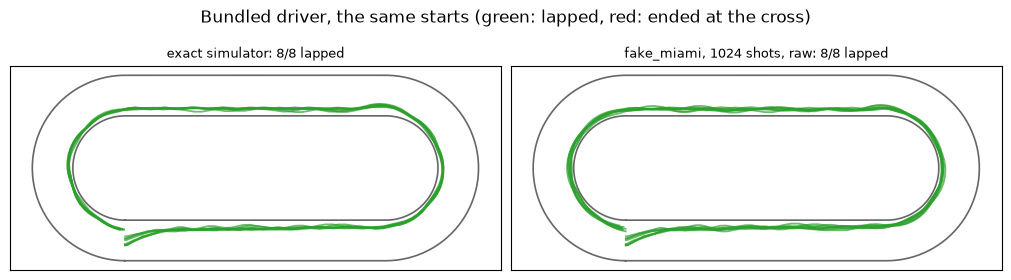

In [10]:
def plot_paths(ax, result, title):
    """Trajectories of one drive() result on the track: lapped green, the rest red."""
    for sign in (+1.0, -1.0):
        edge = track.centerline + sign * track.half_width * track.normals
        edge = np.vstack([edge, edge[:1]])
        ax.plot(edge[:, 0], edge[:, 1], color="0.4", lw=1.2)
    for path, ok in zip(result["paths"], result["lapped"], strict=True):
        ax.plot(path[:, 0], path[:, 1], color="tab:green" if ok else "tab:red", lw=1.3,
                alpha=0.7)
        if not ok:
            ax.plot(*path[-1], "x", color="tab:red", ms=7)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=9)


ROW_HEADER = f"{'lapped':>7}{'ended at':>19}{'jobs':>7}{'per job':>13}"
ROW_FOOTER = ("('ended at': median number of decisions of the episodes that did not lap; "
              f"{LAP_CAP} = still on the track when the episode was cut off)")


def device_row(label, weights, seed, **settings):
    """DEVICE_EPISODES episodes on the simulated device; prints one table row."""
    hw = device_qfunction(weights, seed=seed, **settings)
    t0 = time.perf_counter()
    result = drive(hw, DEVICE_EPISODES)
    result["seconds_per_job"] = (time.perf_counter() - t0) / max(1, hw.jobs)
    crashed = result["decisions"][~result["lapped"]]
    crash = f"{np.median(crashed):.0f}" if crashed.size else "-"
    print(f"  {label:<36}{score(result):>7}{crash:>19}{hw.jobs:>7}"
          f"{1e3 * result['seconds_per_job']:>10.0f} ms")
    return result


if RUN_HW:
    bundled["exact_same_starts"] = drive(fast, DEVICE_EPISODES)
    print(f"bundled driver on {device.name}, {DEVICE_EPISODES} episodes, {SHOTS} shots")
    print(f"  {'setting':<36}{ROW_HEADER}")
    print(f"  {'exact simulator, the same starts':<36}{score(bundled['exact_same_starts']):>7}")
    bundled["device"] = device_row("raw", params, seed=100)
    print(ROW_FOOTER)
    RECAP.append(("laps", f"bundled driver on {device.name}, raw, {SHOTS} shots: "
                  f"{score(bundled['device']).strip()} lapped (exact on the same starts: "
                  f"{score(bundled['exact_same_starts']).strip()})"))

    fig, axes = plt.subplots(1, 2, figsize=(10, 3), layout="constrained")
    plot_paths(axes[0], bundled["exact_same_starts"],
               f"exact simulator: {score(bundled['exact_same_starts']).strip()} lapped")
    plot_paths(axes[1], bundled["device"],
               f"{device.name}, {SHOTS} shots, raw: {score(bundled['device']).strip()} lapped")
    fig.suptitle("Bundled driver, the same starts (green: lapped, red: ended at the cross)")
    plt.show()
else:
    skipped("laps on the device")

Compare the device row with the exact row above it, and with the device
check the sidecar recorded when the driver was chosen (the driver cell at
the top). The two device counts are separate measurements — other spawns,
another simulator seed — of the same thing, and both are small: with this
few episodes a difference of one or two is not a result.

Whatever the count is, it describes *this* driver. The same circuit with
other parameters can read the same track just as well on the exact simulator
and still fall off under noise, because nothing in ordinary training asks
for a margin. The next section shows where the margin comes from.

## 5. Training for the device

Two switches in the trainer aim at the two things section 4 described:

- **`action_gap`** — *advantage learning*: the TD target of the action taken
  is lowered by `action_gap` times its distance to the best action's value.
  The best action is unchanged; the others are pushed further below it, so
  the trained gaps are wider (Baird's advantage learning; see Bellemare et
  al., [*Increasing the Action Gap: New Operators for Reinforcement
  Learning*](https://arxiv.org/abs/1512.04860), AAAI 2016).
- **`act_noise`** — during training the car *acts* on noisy readouts
  (attenuation plus shot noise, the model from section 4.1), and the
  snapshot that is kept is chosen under that noise too. TD targets and
  gradients stay exact. Policies whose driving falls apart under noise never
  look good in training.

Both are off in `[training]` and switched on for the quantum agent on this
track by `[training_presets_quantum.oval]` in the default config, so
`train_headless --agent quantum --track oval` uses them. The bundled driver
was trained that way — for more episodes than the default, and then picked
as the best of several seeds (the next cell prints both episode counts) —
which makes it a poor witness for the *recipe*: a selected driver says what
the best seed can do, not what the switches do.

So this notebook trains a small paired comparison right here: the same
seeds, the default number of episodes, once **plain** (both switches off,
everything else identical) and once **robust** (the config's recipe). The
seeds are ones no study trained on. Two seeds per recipe keep the notebook
affordable — four short training runs on the exact simulator, each of which
prints how long it took — and that is enough to watch the mechanism, not
enough to measure anything about the recipe. What more seeds say comes after the comparison.

In [11]:
from traqmania.agents.training import DQNTrainer
from traqmania.config import resolve_training_cfg
from traqmania.train_headless import save_weights

TRAIN_SEEDS = (200, 201)
SWITCHES = ("action_gap", "act_noise")  # the two options this section is about
# What the trainer uses for the quantum agent on this track, and the same without the switches.
ROBUST = resolve_training_cfg(config, TRACK, agent="quantum")
RECIPES = {
    "plain": {key: value for key, value in ROBUST.items() if key not in SWITCHES},
    "robust": ROBUST,
}
OUT = Path(tempfile.mkdtemp(prefix="traqmania_nb05_"))
DRIVERS = []

print(f"both recipes: {ROBUST['episodes']} episodes per run, seeds {list(TRAIN_SEEDS)}")
print("robust only: " + ", ".join(f"{key} = {ROBUST.get(key, 'off')}" for key in SWITCHES))
print("the bundled driver's sidecar records: "
      + ", ".join(f"{key} = {recipe.get(key, 'off')}" for key in SWITCHES)
      + f", {recipe.get('episodes', '?')} episodes")


def train_driver(name, seed):
    """One training run on the exact simulator; the weights (plus a sidecar that
    records the recipe) go to a temporary directory."""
    cfg = copy.deepcopy(config)
    training = {**RECIPES[name], "seed": seed}
    env = RacingEnv(track, cfg, n_envs=training["n_parallel_envs"], seed=seed)
    qfunc = QuantumQFunction(cfg["circuit"], seed=seed)
    trainer = DQNTrainer(
        qfunc, env, training, rng=np.random.default_rng(seed),
        # periodic greedy evals on distinct episodes; the best snapshot is kept
        env_factory=lambda: RacingEnv(track, cfg, n_envs=trainer.eval_episodes,
                                      seed=seed + 10_000))
    history = trainer.train()
    path = save_weights(qfunc, "quantum", TRACK, cfg, training["episodes"],
                        out_dir=OUT / f"{name}_seed{seed}", training_cfg=training)
    best = history["best_eval"]
    print(f"  {name:<7} seed {seed}: {training['episodes']} episodes, "
          f"{len(history['losses'])} updates in {history['wall_time_s']:.0f} s; kept the "
          f"snapshot of episode {best['episode']} ({best['lapped_episodes']}/"
          f"{best['eval_episodes']} eval episodes lapped"
          + (" under acting noise" if "act_noise" in training else "") + ")")
    return {"recipe": name, "seed": seed, "name": f"{name} {seed}", "path": path,
            "qfunc": qfunc, "updates": len(history["losses"]),
            "seconds": history["wall_time_s"]}


print("\nplain recipe:")
DRIVERS += [train_driver("plain", seed) for seed in TRAIN_SEEDS]

both recipes: 400 episodes per run, seeds [200, 201]
robust only: action_gap = 0.8, act_noise = {'attenuation': 0.95, 'shots': 1024}
the bundled driver's sidecar records: action_gap = 0.8, act_noise = {'attenuation': 0.95, 'shots': 1024}, 800 episodes

plain recipe:


  plain   seed 200: 400 episodes, 5656 updates in 120 s; kept the snapshot of episode 400 (12/12 eval episodes lapped)


  plain   seed 201: 400 episodes, 3614 updates in 69 s; kept the snapshot of episode 400 (12/12 eval episodes lapped)


In [12]:
print("robust recipe:")
DRIVERS += [train_driver("robust", seed) for seed in TRAIN_SEEDS]

robust recipe:


  robust  seed 200: 400 episodes, 3901 updates in 77 s; kept the snapshot of episode 250 (12/12 eval episodes lapped under acting noise)


  robust  seed 201: 400 episodes, 10011 updates in 139 s; kept the snapshot of episode 400 (12/12 eval episodes lapped under acting noise)


Same yardstick as before for all of them: laps on the exact simulator and
under the emulated device, plus the margin statistics from section 4.2. The
figure compares the gap distributions — the quantity `action_gap` is meant
to move. The bundled driver is the last row; remember that it trained for
longer and was selected.

episodes that lapped, of 36 (emulation model: fitted to fake_miami)
driver            exact  emulated  mean |w|  median gap  gap / sigma  under 1 sigma


plain 200         36/36     24/36      27.9        0.39         0.93            53%


plain 201         36/36     11/36      17.2        0.10         0.60            75%


robust 200        36/36     36/36       7.0        0.89         3.80             6%


robust 201        30/36     32/36      40.0        2.00         3.63            12%
bundled           36/36     36/36      65.1        8.17         5.11            17%


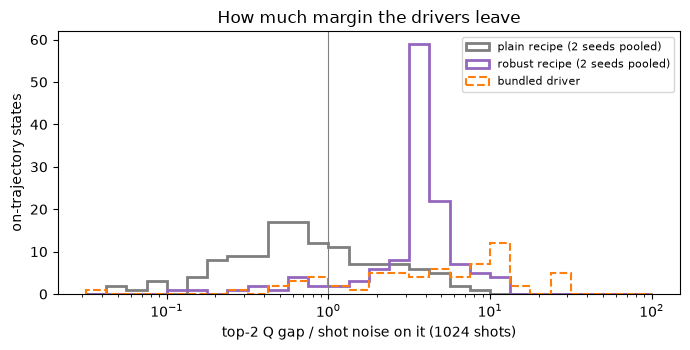

In [13]:
def laps_of(driver, key):
    return int(driver[key]["lapped"].sum()) if key in driver else 0


print(f"episodes that lapped, of {EPISODES} (emulation model: {MODEL_SOURCE})")
print(f"{'driver':<16}{'exact':>7}{'emulated':>10}{'mean |w|':>10}{'median gap':>12}"
      f"{'gap / sigma':>13}{'under 1 sigma':>15}")
for k, driver in enumerate(DRIVERS):
    qf = driver["qfunc"]
    driver["exact"] = drive(qf, EPISODES)
    driver["emulated"] = drive(emulated(qf, DEVICE_MODEL, seed=50 + k), EPISODES)
    driver["gap"], driver["gap_sigma"] = margins(qf)
    print(f"{driver['name']:<16}{score(driver['exact']):>7}"
          f"{score(driver['emulated']):>10}{np.mean(np.abs(qf.w)):>10.1f}"
          f"{np.median(driver['gap']):>12.2f}{np.median(driver['gap_sigma']):>13.2f}"
          f"{np.mean(driver['gap_sigma'] < 1):>15.0%}")
print(f"{'bundled':<16}{score(bundled['exact']):>7}{score(bundled['emulated']):>10}"
      f"{np.mean(np.abs(fast.w)):>10.1f}{np.median(gap):>12.2f}{np.median(gap_sigma):>13.2f}"
      f"{np.mean(gap_sigma < 1):>15.0%}")
for name in RECIPES:
    group = [d for d in DRIVERS if d["recipe"] == name]
    RECAP.append(("training", f"{name} recipe, seeds {list(TRAIN_SEEDS)}: laps of {EPISODES} "
                  f"exact {[laps_of(d, 'exact') for d in group]}, emulated device "
                  f"{[laps_of(d, 'emulated') for d in group]}; median gap/sigma "
                  f"{[round(float(np.median(d['gap_sigma'])), 1) for d in group]}"))

fig, ax = plt.subplots(figsize=(7, 3.6))
bins = np.logspace(-1.5, 2.0, 29)
colors = {"plain": "tab:gray", "robust": "tab:purple"}
for name, color in colors.items():
    pooled = np.concatenate([d["gap_sigma"] for d in DRIVERS if d["recipe"] == name])
    ax.hist(np.clip(pooled, bins[0], bins[-1]), bins=bins, histtype="step", lw=2, color=color,
            label=f"{name} recipe ({len(TRAIN_SEEDS)} seeds pooled)")
ax.hist(np.clip(gap_sigma, bins[0], bins[-1]), bins=bins, histtype="step", lw=1.5, ls="--",
        color="tab:orange", label="bundled driver")
ax.axvline(1.0, color="0.5", lw=0.8)
ax.set_xscale("log")
ax.set(xlabel=f"top-2 Q gap / shot noise on it ({SHOTS} shots)", ylabel="on-trajectory states",
       title="How much margin the drivers leave")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The emulation is a screening tool. The number that counts is the device
path: every trained driver, the same starts, raw (resilience 0, no rescale).
A driver that does not lap on the exact simulator has nothing to lose, so
compare each device row with its own "exact" count (a noisy driver can also
get round where the exact one does not). The second table counts flipped
decisions the way section 4.2 did, with one job per driver.

In [14]:
def device_flips(driver, jobs=1):
    """Share of on-trajectory decisions (FLIP_STATES states x `jobs` jobs at SHOTS
    shots) in which the device's greedy action differs from the exact one."""
    qf = driver["qfunc"]
    obs = noise.trajectory_states(qf, TRACK, config, FLIP_STATES, seed=EVAL_SEED)
    greedy = np.argmax(qf.q_values(obs), axis=1)
    hw = device_qfunction(qf.get_params(), seed=300 + driver["seed"])
    return float(np.mean([np.argmax(hw.q_values(obs), axis=1) != greedy for _ in range(jobs)]))


if RUN_HW:
    print(f"trained drivers on {device.name}, {DEVICE_EPISODES} episodes each, {SHOTS} shots, "
          f"raw")
    print(f"  {'driver (exact on the same starts)':<36}{ROW_HEADER}")
    for k, driver in enumerate(DRIVERS):
        driver["exact_same_starts"] = drive(driver["qfunc"], DEVICE_EPISODES)
        label = f"{driver['name']} ({score(driver['exact_same_starts']).strip()})"
        driver["device"] = device_row(label, driver["qfunc"].get_params(), seed=1000 * (k + 1))
    print(f"  {'bundled (' + score(bundled['exact_same_starts']).strip() + '), section 4.3':<36}"
          f"{score(bundled['device']):>7}")
    print(ROW_FOOTER)

    print(f"\non-trajectory decisions that differ from the exact policy on {device.name} "
          f"({SHOTS} shots)")
    for driver in DRIVERS:
        driver["flips"] = device_flips(driver)
        print(f"  {driver['name']:<16}{driver['flips']:>5.0%}   ({FLIP_STATES} states x 1 job)")
    print(f"  {'bundled':<16}{flips['device_flip_rate']:>5.0%}   ({flips['states']} states x "
          f"{flips['repeats']} jobs, section 4.2)")
    for name in RECIPES:
        group = [d for d in DRIVERS if d["recipe"] == name]
        RECAP.append(("training", f"{name} recipe on {device.name}, laps of "
                      f"{DEVICE_EPISODES} at {SHOTS} shots raw: "
                      f"{[laps_of(d, 'device') for d in group]} (exact on the same starts: "
                      f"{[laps_of(d, 'exact_same_starts') for d in group]}); decisions "
                      f"flipped: {[format(d['flips'], '.0%') for d in group]}"))
else:
    skipped("trained drivers on the device")


def lost(driver):
    """Laps the noise cost a driver: on the device path when it ran, else under emulation."""
    if "device" in driver:
        return laps_of(driver, "exact_same_starts") - laps_of(driver, "device")
    return laps_of(driver, "exact") - laps_of(driver, "emulated")


# The contrast for the rest of the notebook: the plain-recipe driver the noise cost the
# most laps (ties: the one that laps more often on the exact simulator, then the one
# with the thinner margins).
CONTRAST = max((d for d in DRIVERS if d["recipe"] == "plain"),
               key=lambda d: (lost(d), laps_of(d, "exact"), -np.median(d["gap_sigma"])))
print(f"\ncontrast driver for sections 6 and 8: {CONTRAST['name']} (lost {lost(CONTRAST)} "
      f"laps to the {'device' if 'device' in CONTRAST else 'emulated'} noise)")

trained drivers on fake_miami, 8 episodes each, 1024 shots, raw
  driver (exact on the same starts)    lapped           ended at   jobs      per job


  plain 200 (8/8)                         8/8                  -    168       333 ms


  plain 201 (8/8)                         5/8                 65    148       344 ms


  robust 200 (8/8)                        8/8                  -    152       386 ms


  robust 201 (5/8)                        7/8                250    250       302 ms
  bundled (8/8), section 4.3              8/8
('ended at': median number of decisions of the episodes that did not lap; 250 = still on the track when the episode was cut off)

on-trajectory decisions that differ from the exact policy on fake_miami (1024 shots)


  plain 200         43%   (64 states x 4 jobs)


  plain 201         41%   (64 states x 4 jobs)


  robust 200         2%   (64 states x 4 jobs)


  robust 201         5%   (64 states x 4 jobs)
  bundled            6%   (64 states x 8 jobs, section 4.2)

contrast driver for sections 6 and 8: plain 201 (lost 3 laps to the device noise)


What this comparison can and cannot say. There are three things to look at:
the margins (gap / sigma and the share of states under one sigma), the
flipped decisions on the device, and the laps. Margins and flips are where
the two switches act directly, and a difference there shows even with two
seeds if the recipe does what it is meant to. Laps are a coarser and noisier
signal: a plain driver can flip many decisions and still get round, because
flips between near-equivalent actions cost nothing, and a robust-recipe seed
can fail to learn the whole lap within the budget, noise or no noise. With
two seeds per recipe and eight device episodes, lap counts show a direction
at best; they do not give a success rate. And the contrast driver was picked
as the plain driver that lost the most, so it is the worst case of a small
sample by construction, not a typical plain driver.

### What many seeds say

The studies behind the recipe trained more seeds for longer. Their compact
summaries ship with the repository (`data/studies/`, written by
`tools/study.py` and `tools/export_study.py`); the cell tabulates the ones
for this track. Each run is evaluated on distinct greedy episodes on the
**exact simulator** — these are statements about training, not about the
device:

- *best-snapshot lapped* — the share of evaluation episodes the kept
  snapshot laps;
- *final-parameters lapped* — the same for the parameters at the end of
  training, without snapshot selection;
- *stability* — the mean lapped share over all in-training evaluations
  after the first one that lapped: how well a run holds on to what it found.

Values are interquartile means over seeds with 95 % bootstrap intervals.
Under the table the cell says, for three pairs of rows, on which columns the
two intervals do not overlap and which row is ahead there.

In [15]:
STUDY_ROWS = (  # (study directory, variant, what it is)
    ("oval_4q", "base", "the pre-audit trainer"),
    ("oval_4q", "trunc", "the plain recipe of this section, in longer runs"),
    ("robust_oval_4q", "gap8an", "the robust recipe of this section, in longer runs"),
    ("oval_4q", "mlp_trunc", "the classical MLP baseline, plain recipe"),
)
STUDY_COLUMNS = (  # (metric, column title, number format, +1 if higher is better else -1)
    ("best_lapped_frac", "best-snapshot lapped", "{:.2f}", +1),
    ("final_lapped_frac", "final-params lapped", "{:.2f}", +1),
    ("stability", "stability", "{:.2f}", +1),
    ("best_mean_lap", "mean lap (s)", "{:.1f}", -1),
    ("first_clean_episode", "first clean lap (ep.)", "{:.0f}", -1),
)
STUDY_PAIRS = (("gap8an", "trunc"), ("mlp_trunc", "trunc"), ("mlp_trunc", "gap8an"))
studies = next((base / "data" / "studies" for base in [Path.cwd(), *Path.cwd().parents]
                if (base / "data" / "studies").is_dir()), None)
if studies is None:
    print("data/studies not found (running outside the repository checkout): no study table")
else:
    def cell(metric, fmt):
        stat = metric["iqm"]
        return (f"{fmt.format(stat['value'])} [{fmt.format(stat['ci_low'])}, "
                f"{fmt.format(stat['ci_high'])}]")

    print(f"{TRACK}, {N_QUBITS} qubits, exact simulator; IQM over seeds [95% CI]")
    print(f"{'variant':<11}{'agent':<9}{'params':>6}{'seeds':>6}{'episodes':>9}"
          + "".join(f"{title:>23}" for _, title, _, _ in STUDY_COLUMNS))
    found, notes = {}, []
    for directory, variant, what in STUDY_ROWS:
        path = studies / directory / "report.json"
        report = json.loads(path.read_text(encoding="utf-8")) if path.is_file() else {}
        if variant not in report.get("variants", {}):
            print(f"{variant:<11}(not found in {directory}/report.json)")
            continue
        found[variant] = v = report["variants"][variant]
        print(f"{variant:<11}{v['recipe']['agent']:<9}{v['n_params']:>6}{v['n_seeds']:>6}"
              f"{v['recipe']['episodes']:>9}"
              + "".join(f"{cell(v['metrics'][key], fmt):>23}"
                        for key, _, fmt, _ in STUDY_COLUMNS))
        notes.append(f"  {variant}: {what} (data/studies/{directory}, "
                     f"{report['eval']['episodes']} eval episodes per run; overrides: "
                     f"{', '.join(v['recipe']['overrides']) or 'none'})")
    print("\n".join(notes))

    print("\ncolumns on which the 95% intervals of two rows do not overlap:")
    for first, second in STUDY_PAIRS:
        if first not in found or second not in found:
            continue
        ahead, behind = [], []
        for key, title, _, sign in STUDY_COLUMNS:
            a, b = (found[name]["metrics"][key]["iqm"] for name in (first, second))
            if a["ci_low"] > b["ci_high"] or a["ci_high"] < b["ci_low"]:
                (ahead if sign * (a["value"] - b["value"]) > 0 else behind).append(title)
        verdict = "; ".join(
            ([f"{first} ahead on {', '.join(ahead)}"] if ahead else [])
            + ([f"{second} ahead on {', '.join(behind)}"] if behind else [])) or "none"
        print(f"  {first} against {second}: {verdict}")
        RECAP.append(("studies", f"{first} ({found[first]['n_seeds']} seeds) against {second} "
                      f"({found[second]['n_seeds']} seeds), non-overlapping 95% intervals: "
                      f"{verdict}"))

oval, 4 qubits, exact simulator; IQM over seeds [95% CI]
variant    agent    params seeds episodes   best-snapshot lapped    final-params lapped              stability           mean lap (s)  first clean lap (ep.)
base       quantum      56     8      800      1.00 [0.98, 1.00]      0.52 [0.01, 1.00]      0.58 [0.49, 0.71]      13.8 [13.1, 14.3]         294 [238, 369]
trunc      quantum      56     8      800      1.00 [0.98, 1.00]      0.84 [0.57, 0.97]      0.69 [0.57, 0.75]      13.9 [13.3, 14.4]         294 [238, 369]
gap8an     quantum      56    10      800      1.00 [0.94, 1.00]      0.80 [0.47, 0.99]      0.75 [0.52, 0.92]      13.7 [13.2, 14.1]         264 [236, 341]
mlp_trunc  mlp          76     8      800      1.00 [1.00, 1.00]      1.00 [0.98, 1.00]      0.94 [0.87, 0.99]      12.9 [12.6, 13.2]         153 [134, 168]
  base: the pre-audit trainer (data/studies/oval_4q, 36 eval episodes per run; overrides: none)
  trunc: the plain recipe of this section, in longer runs (dat

How to read it:

- **The rows are separate studies of different size.** The robust recipe was
  trained on more seeds than the others, in its own campaign. Intervals that
  do not overlap are a conservative sign of a real difference; intervals
  that overlap settle nothing either way.
- **What the circuit rows can show** is whether the robust recipe costs
  anything on the exact simulator — reliability, stability, pace, episodes
  until the first clean lap — compared with the plain one. They are not
  evidence about the device: the summaries hold no device laps.
- **The classical baseline is the last row**: a small MLP with a comparable
  number of parameters, the same trainer and budget. The comparison lines
  say where it is ahead of the circuit; nothing in this notebook changes
  that. Device noise is a handicap only the circuit has, and the recipe of
  this section exists to cope with it.
- **Device laps over more seeds** are in `docs/SCIENCE.md` ("Hardware"),
  from `tools/hw_reliability.py`; the candidates table at the top of this
  notebook is the device check of the top-ranked seeds of the robust study.

## 6. Mitigation at inference time

Everything in section 5 changed the *driver*. Inference-side mitigation
leaves the driver alone and changes how its readouts are measured or
corrected:

- **more shots** — less shot noise, the systematic part untouched;
- **`rescale="readout"`** — one calibration job, then every readout is
  corrected for its own fitted slope and bias (and its shot noise is
  amplified by one over the slope);
- **TREX** (`resilience_level=1`) — readout-error mitigation by the
  Estimator, at the price of extra circuits per job.

The cell runs the three on the same starts as before, for the contrast
driver of section 5 and for the bundled driver. The raw rows are the ones
already measured.

In [16]:
if RUN_HW:
    SETTINGS = {
        f"{4 * SHOTS} shots": {"shots": 4 * SHOTS},
        f"{4 * SHOTS} shots + readout rescale": {"shots": 4 * SHOTS, "rescale": "readout"},
        "TREX (resilience 1)": {"resilience_level": 1},
    }

    def mitigation_rows(name, driver, weights, seed):
        """The SETTINGS on the device for one driver, after its exact and raw rows."""
        print(f"{name} on {device.name}, {DEVICE_EPISODES} episodes per setting "
              f"({SHOTS} shots unless stated)")
        print(f"  {'setting':<36}{ROW_HEADER}")
        print(f"  {'exact simulator, the same starts':<36}"
              f"{score(driver['exact_same_starts']):>7}")
        print(f"  {'raw (measured above)':<36}{score(driver['device']):>7}")
        rows = {"raw": driver["device"]}
        for k, (label, settings) in enumerate(SETTINGS.items()):
            rows[label] = device_row(label, weights, seed=seed + 100 * k, **settings)
        RECAP.append(("mitigation", f"{name} on {device.name}, laps of {DEVICE_EPISODES} "
                      f"(exact {score(driver['exact_same_starts']).strip()}): "
                      + "; ".join(f"{label} {score(r).strip()}" for label, r in rows.items())))
        return rows

    contrast_rows = mitigation_rows(f"contrast driver ({CONTRAST['name']})", CONTRAST,
                                    CONTRAST["qfunc"].get_params(), seed=2000)
    print()
    bundled_rows = mitigation_rows("bundled driver", bundled, params, seed=200)
    print(ROW_FOOTER)
else:
    skipped("mitigation rows on the device")

contrast driver (plain 201) on fake_miami, 8 episodes per setting (1024 shots unless stated)
  setting                              lapped           ended at   jobs      per job
  exact simulator, the same starts        8/8
  raw (measured above)                    5/8


  4096 shots                              6/8                 76    147       383 ms


  4096 shots + readout rescale            6/8                129    150       486 ms


  TREX (resilience 1)                     3/8                 69    152      2290 ms

bundled driver on fake_miami, 8 episodes per setting (1024 shots unless stated)
  setting                              lapped           ended at   jobs      per job
  exact simulator, the same starts        8/8
  raw (measured above)                    8/8


  4096 shots                              8/8                  -    140      1198 ms


  4096 shots + readout rescale            8/8                  -    141      1040 ms


  TREX (resilience 1)                     8/8                  -    140      3280 ms
('ended at': median number of decisions of the episodes that did not lap; 250 = still on the track when the episode was cut off)


Read each block against its first two rows. Where the raw row already
matches the exact one there is nothing left to buy back, and the mitigation
rows show only what they cost — the time per job, and for the rescale one
calibration job up front — and whether they do any harm. Where the raw row
is short, the other rows show how much of the loss comes back — or that
none does. A mitigation row can also come out *below* the raw row; with
eight episodes that is within what chance produces, so read it as "no
rescue here", not as proof of harm. A difference of one or two episodes out
of this few is not a result in either direction.

Mitigation has limits that no setting removes. The rescale undoes an
*average* slope and bias, not the part of the error that depends on the
state; TREX corrects readout errors, not gate errors; more shots only help
with the random part. None of them widens a gap that training left thin:
they shrink the noise the gap is compared with.

### A lap where every decision is a quantum job

`run_hardware_lap` is what the game's hardware panel and the CLI
(`python -m traqmania.hardware lap --fake`) call: one car, one spawn that
none of the tables above used, each decision one job inside whatever
execution mode the backend grants. Once for the bundled driver, once for
the contrast driver. These are **single runs** — an illustration of the
loop; the tables above are the evidence.

bundled driver:


  runs on: fake_miami (4-qubit patch: physical qubits 4, 5, 14, 15)  [session mode]
  circuit: 12 two-qubit gates, depth 39 (light-cone pruned); 1024 shots per decision; raw device noise, no error mitigation


  lapped in 14.0 s; 140 jobs, 194 ms per decision
contrast driver (plain 201):
  runs on: fake_miami (4-qubit patch: physical qubits 4, 5, 14, 15)  [session mode]
  circuit: 12 two-qubit gates, depth 39 (light-cone pruned); 1024 shots per decision; raw device noise, no error mitigation


  lapped in 14.5 s; 145 jobs, 588 ms per decision


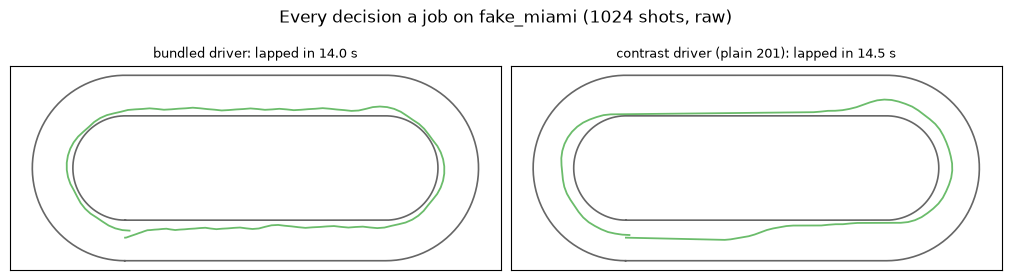

In [17]:
if RUN_HW:
    def report(info):
        print(f"  runs on: {info['backend_name']}  [{info['mode']} mode"
              + (f"; {info['note']}" if info["note"] else "") + "]")
        print(f"  circuit: {info['two_qubit_gates']} two-qubit gates, depth {info['depth']}"
              f"{' (light-cone pruned)' if info['pruned'] else ''}; {info['shots']} shots per "
              f"decision; {hardware.mitigation_text(info)}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3), layout="constrained")
    for ax, (name, weights) in zip(
            axes, (("bundled driver", WEIGHTS),
                   (f"contrast driver ({CONTRAST['name']})", CONTRAST["path"])), strict=True):
        print(f"{name}:")
        lap = hardware.run_hardware_lap(TRACK, weights, device, shots=SHOTS,
                                        max_decisions=LAP_CAP, config=config, on_start=report,
                                        seed_simulator=7)
        verdict = (f"lapped in {lap['best_lap_s']:.1f} s" if lap["lapped"]
                   else f"no lap ({lap['decisions']} decisions)")
        print(f"  {verdict}; {lap['decisions']} jobs, "
              f"{1e3 * lap['seconds_per_decision']:.0f} ms per decision")
        RECAP.append(("laps", f"single hardware lap, {name}: {verdict}"))
        path = np.array(lap["trajectory"])[:, :2]
        plot_paths(ax, {"paths": [path], "lapped": [lap["lapped"]]}, f"{name}: {verdict}")
    fig.suptitle(f"Every decision a job on {device.name} ({SHOTS} shots, raw)")
    plt.show()
else:
    skipped("a lap with every decision on the device")

## 7. Why training stays on the simulator

Could we have *trained* on hardware instead of only driving there? Count
what one double-DQN gradient step costs.

- On the simulator the gradient of all parameters comes from one **adjoint**
  pass ([notebook 03](03_quantum_circuits_as_q_functions.ipynb)).
- On hardware there is no adjoint. The **parameter-shift rule** needs two
  circuit evaluations *per circuit parameter*: every encoding scale
  $\lambda_{l,i}$ and every variational angle $\theta_{l,i,k}$ whose gate
  survives light-cone pruning. (Parameters of pruned gates have exactly zero
  gradient, and the head $w, b$ needs no circuit at all.) Each evaluation is
  one Estimator job with one row per replay sample.

The cell counts those jobs for the current circuit, times the exact gradient
and — when the hardware path is available — one such job on the simulated
device, and multiplies out a whole training run of the length used in
section 5 (the median number of updates of the runs trained there; the
bundled driver's own run had more episodes).

In [18]:
mask = lightcone.live_parameter_mask(N_QUBITS, N_LAYERS, N_ACTIONS)
circuit_parameters = mask["lam"].size + mask["theta"].size
live_parameters = int(mask["lam"].sum() + mask["theta"].sum())
shift_jobs = 2 * live_parameters
batch = int(config["training"]["batch_size"])
updates = int(np.median([d["updates"] for d in DRIVERS]))

rng = np.random.default_rng(0)
obs_b = rng.uniform(0.0, 1.0, size=(batch, fast.n_features))
act_b = rng.integers(N_ACTIONS, size=batch)
timings = []
for _ in range(20):
    t0 = time.perf_counter()
    fast.grad_selected(obs_b, act_b, np.ones(batch))
    timings.append(time.perf_counter() - t0)
adjoint_s = float(np.median(timings))

print(f"circuit parameters: {circuit_parameters} (+ {fast.n_params - circuit_parameters} in "
      f"the classical head); inside the light cone: {live_parameters}")
print(f"parameter-shift: 2 x {live_parameters} = {shift_jobs} jobs per update, each "
      f"{batch} rows x {SHOTS} shots = {shift_jobs * batch * SHOTS:,} shots per update")
print(f"a training run as in section 5: {updates:,} updates "
      f"= {updates * shift_jobs:,} jobs = {updates * shift_jobs * batch * SHOTS:.1e} shots")
print(f"\nexact gradient of a batch (fastsim + adjoint): {1e3 * adjoint_s:.1f} ms "
      f"-> {updates * adjoint_s:.0f} s of gradients per run")
RECAP.append(("cost", f"parameter-shift: {shift_jobs} jobs per update (2 x {live_parameters} "
              f"live circuit parameters); {updates * shift_jobs:,} jobs for a "
              f"{updates:,}-update run"))
if RUN_HW:
    hw = device_qfunction(params, seed=5)
    hw.q_values(obs_b)  # warm-up
    t0 = time.perf_counter()
    for _ in range(5):
        hw.q_values(obs_b)
    job_s = (time.perf_counter() - t0) / 5
    print(f"one job of {batch} rows on the local twin of {device.name}: {job_s:.2f} s "
          f"-> {shift_jobs * job_s:.0f} s per update, "
          f"{updates * shift_jobs * job_s / 3600:.0f} hours per run "
          f"({shift_jobs * job_s / adjoint_s:,.0f} x the adjoint)")
    print("on a real QPU each of those jobs also pays latency and, without a Session, the "
          "queue")
    RECAP.append(("cost", f"on the local twin that is {shift_jobs * job_s:.0f} s per update "
                  f"against {1e3 * adjoint_s:.1f} ms for the adjoint: "
                  f"{updates * shift_jobs * job_s / 3600:.0f} hours per run"))
else:
    skipped("timing one such job on the simulated device")

circuit parameters: 48 (+ 8 in the classical head); inside the light cone: 44
parameter-shift: 2 x 44 = 88 jobs per update, each 32 rows x 1024 shots = 2,883,584 shots per update
a training run as in section 5: 4,778 updates = 420,464 jobs = 1.4e+10 shots

exact gradient of a batch (fastsim + adjoint): 3.3 ms -> 16 s of gradients per run


one job of 32 rows on the local twin of fake_miami: 1.42 s -> 125 s per update, 166 hours per run (38,084 x the adjoint)
on a real QPU each of those jobs also pays latency and, without a Session, the queue


The simulated device is the *cheap* case: no queue, no network, no
per-job overhead of a real system. Whatever the last lines print, a real
QPU makes it worse. Hence traQmania's split: **train on the exact
simulator, run inference on hardware.**

## 8. The hardware sprint: SPSA

There is a middle path for *adjusting* trained weights on hardware:
**SPSA** (simultaneous perturbation stochastic approximation; Spall 1992,
reference in `docs/SCIENCE.md`). Instead of two evaluations per parameter it
perturbs all parameters at once along a random ±1 direction $\Delta$,
evaluates the loss at $\theta \pm c\Delta$, and steps along the estimated
slope: **two loss evaluations per iteration, whatever the number of
parameters.** `traqmania.hardware.spsa_sprint` does this for the TD loss:
the replay batch and the TD targets are computed once on the exact
simulator, and each loss evaluation is one Estimator job.

**The first version of this sprint was not safe to run.** It ran plain SPSA
over all parameters, circuit angles and head alike, with one probe size and
a step size calibrated on a single probe pair, and it always descended the
plain double-DQN loss, whatever target the driver had been trained on. One
evaluation of the loss on a device is about as noisy as the difference
between the two probes, so a step is largely a random walk, and a single
probe pair that happens to land on a flat direction inflates every later
step. The seeded runs behind the fix (`docs/SCIENCE.md`, "Hardware") were
made on the bundled driver of that time, which decided on very thin margins
— about one sigma of shot noise at the median, by the measure of section
4.2. That recipe cost it its policy in most of those sprints, sometimes
while the loss it measured went *down*.

What the sprint does now (all defaults; each can be switched off):

- **Head only.** SPSA moves just the output head $w, b$. To first order a
  device's error is a slope and a bias per readout — exactly what the head
  can absorb — and two parameters per action are few enough for a
  two-evaluation gradient to mean something.
- **A calibrated, bounded step.** Probes are sized per parameter group, the
  gain is calibrated on several probe pairs instead of one, and each step is
  clipped to a trust region.
- **Blocking.** A step is taken only if the hardware loss at the proposed
  parameters is not worse than at the current ones (one more job).
- **A simulator guard.** A step is refused, before any job is spent on it,
  if it would cost the policy more than a set share (a tenth by default) of
  its greedy return on the *exact simulator*. The loss sees a handful of
  replay rows; whether the car still drives is a different question, and for
  circuits this small the simulator answers it.
- **Honest bookkeeping.** `loss_before` / `loss_after` are means of fresh
  evaluations, not the values the blocking rule selected on; the returns are
  means over several episodes instead of one; and the TD targets follow the
  recipe recorded in the weights' sidecar (so a driver trained with
  `action_gap` is fine-tuned on its own kind of target).

The cell runs three sprints per seed (the seed sets the replay batch, the
SPSA directions and the shot noise) on the bundled driver and on the
contrast driver of section 5:

1. **the original recipe**, rebuilt here from the same building blocks the
   module uses (`traqmania.agents.training.spsa` plus the sprint's own
   replay-batch helper), because the module no longer offers it;
2. **the current code with its safeguards off** — all parameters, every
   step taken, no guard, but still with the calibrated, bounded step;
3. **the current defaults.**

For each run: the hardware loss, the greedy return on the exact simulator
before → after, and laps over the notebook's own evaluation episodes, which
no sprint ever looked at.

In [19]:
from traqmania.agents.training import spsa

SPRINT_SEEDS = (0, 1, 2)
SPRINT_ITERATIONS = 10
SPRINT_BATCH = 16  # replay rows per loss evaluation (spsa_sprint's default)


def sprint_config(seed):
    cfg = load_config()
    cfg["training"]["seed"] = seed  # replay batch, SPSA directions, return episodes
    return cfg


def sprint(weights, seed, **options):
    """traqmania.hardware.spsa_sprint on the simulated device."""
    return hardware.spsa_sprint(TRACK, weights, device, iterations=SPRINT_ITERATIONS,
                                shots=SHOTS, batch=SPRINT_BATCH, config=sprint_config(seed),
                                seed_simulator=seed, **options)


def original_sprint(weights, seed):
    """The sprint as first shipped: plain SPSA over all parameters with one probe
    size (c = 0.1), the gain calibrated on ONE probe pair, every step taken, the
    plain double-DQN target whatever the sidecar records. Rebuilt from the
    sprint's own helpers; returns the same fields as `sprint`."""
    cfg = with_weights_config(sprint_config(seed), Path(weights))
    start = np.load(weights)["params"]
    qf = QuantumQFunction(cfg["circuit"], seed=seed)
    qf.set_params(start)
    obs_b, act_b, target_b = hardware._collect_batch(qf, TRACK, cfg, SPRINT_BATCH, seed)
    hw = device_qfunction(start, seed=seed)
    rows = np.arange(SPRINT_BATCH)

    def loss(x):
        hw.set_params(x)
        return float(np.mean((hw.q_values(obs_b)[rows, act_b] - target_b) ** 2))

    def simulator_return(x):
        qf.set_params(x)
        return hardware._greedy_return(qf, TRACK, cfg, seed,
                                       episodes=hardware.SPRINT_EVAL_EPISODES)

    stability = SPRINT_ITERATIONS / 10.0
    gain, _ = spsa.calibrate_gain(loss, start, c=0.1, target_step=0.01, A=stability, pairs=1,
                                  seed=seed)
    out = spsa.minimize(loss, start, iterations=SPRINT_ITERATIONS, a=gain, c=0.1, A=stability,
                        seed=seed)
    jobs = hw.jobs  # the sprint itself: 2 for the gain + 2 per iteration
    fresh = [(loss(start), loss(out["x"])) for _ in range(hardware.SPRINT_LOSS_EVALUATIONS)]
    loss_before, loss_after = np.mean(fresh, axis=0)  # extra jobs, for this table only
    return {"params": out["x"], "accepted": out["accepted"], "vetoed": out["vetoed"],
            "jobs": jobs, "loss_before": loss_before, "loss_after": loss_after,
            "return_before": simulator_return(start), "return_after": simulator_return(out["x"])}


def safeguards_off(weights, seed):
    return sprint(weights, seed, groups=("lam", "theta", "head"), blocking=False, guard=0.0)


VARIANTS = {"original recipe (rebuilt)": original_sprint,
            "current code, safeguards off": safeguards_off,
            "current defaults": sprint}


def fresh_laps(weights_params):
    qf = QuantumQFunction(config["circuit"])
    qf.set_params(weights_params)
    return int(drive(qf, EPISODES)["lapped"].sum())


def run_sprints(name, weights, laps_before):
    sprints = {}
    print(f"{name}: {SPRINT_ITERATIONS} iterations on {device.name}, {SHOTS} shots; "
          f"simulator return = mean of {hardware.SPRINT_EVAL_EPISODES} episodes; "
          f"laps of {EPISODES} before any sprint: {laps_before}")
    print(f"  {'variant':<30}{'seed':>5}{'steps':>7}{'hardware loss':>20}"
          f"{'simulator return':>22}{'laps after':>12}{'jobs':>6}")
    for variant, run in VARIANTS.items():
        for seed in SPRINT_SEEDS:
            r = run(weights, seed)
            r["laps_after"] = fresh_laps(r["params"])
            sprints[variant, seed] = r
            print(f"  {variant:<30}{seed:>5}{sum(r['accepted']):>4}/{len(r['accepted'])}"
                  f"{r['loss_before']:>10.1f} -> {r['loss_after']:<7.1f}"
                  f"{r['return_before']:>11.0f} -> {r['return_after']:<8.0f}"
                  f"{r['laps_after']:>9}{r['jobs']:>9}")
        runs = [sprints[variant, seed] for seed in SPRINT_SEEDS]
        kept = sum(r["return_after"] >= 0.8 * r["return_before"] for r in runs)
        RECAP.append(("sprint", f"{name}, {variant}: {kept}/{len(runs)} sprints kept >= 80% "
                      f"of their simulator return; laps of {EPISODES}: {laps_before} -> "
                      f"{[r['laps_after'] for r in runs]}"))
    return sprints


def job_breakdown(result):
    """Where a default sprint's Estimator jobs go (see the spsa_sprint docstring)."""
    parts = {"gain calibration": 2 * hardware.SPRINT_CALIBRATION_PAIRS,
             "probes": 2 * len(result["accepted"])}
    if result["blocking"]:
        parts["blocking checks"] = 1 + sum(not veto for veto in result["vetoed"])
    parts["before/after loss"] = hardware.SPRINT_LOSS_EVALUATIONS * (
        2 if any(result["accepted"]) else 1)
    return parts


if RUN_HW:
    bundled_sprints = run_sprints("bundled driver", WEIGHTS, laps_of(bundled, "exact"))
    print()
    contrast_sprints = run_sprints(f"contrast driver ({CONTRAST['name']})", CONTRAST["path"],
                                   laps_of(CONTRAST, "exact"))
    print(f"\njobs of the original recipe: 2 + 2 x {SPRINT_ITERATIONS} = "
          f"{2 + 2 * SPRINT_ITERATIONS}")
    last = bundled_sprints["current defaults", SPRINT_SEEDS[-1]]
    parts = job_breakdown(last)
    print("jobs of the last default sprint of the bundled driver: "
          + " + ".join(f"{n} {what}" for what, n in parts.items())
          + f" = {sum(parts.values())} (the sprint counted {last['jobs']})")
    print(f"  its steps: {hardware.sprint_steps_text(last)}")
else:
    skipped("SPSA sprints on the device")

bundled driver: 10 iterations on fake_miami, 1024 shots; simulator return = mean of 12 episodes; laps of 36 before any sprint: 36
  variant                        seed  steps       hardware loss      simulator return  laps after  jobs


  original recipe (rebuilt)         0  10/10      82.8 -> 60.1          1890 -> 1877           36       22


  original recipe (rebuilt)         1  10/10     159.1 -> 75.0          1890 -> 1911           36       22


  original recipe (rebuilt)         2  10/10     759.8 -> 664.9         1891 -> 1891           36       22


  current code, safeguards off      0  10/10      37.4 -> 26.4          1890 -> 1871           36       34


...

  current code, safeguards off      1  10/10       6.8 -> 5.2           1764 -> 1602           33       34


  current code, safeguards off      2  10/10      11.0 -> 9.1           1762 -> 1769           35       34


  current defaults                  0   0/10       6.5 -> 6.5           1762 -> 1762           36       41


  current defaults                  1   5/10       7.4 -> 7.2           1764 -> 1692           34       45


  current defaults                  2   5/10      11.6 -> 9.2           1762 -> 1683           31       44

jobs of the original recipe: 2 + 2 x 10 = 22
jobs of the last default sprint of the bundled driver: 8 gain calibration + 20 probes + 11 blocking checks + 6 before/after loss = 45 (the sprint counted 45)
  its steps: 1/10 (9 did not lower the hardware loss)


How to read the tables:

- **Simulator return.** With the guard on, the return after cannot fall
  below the guarded share of the return before — *by construction*: the
  guard checks the very episodes these two numbers are computed from. It is
  a safety rule, not evidence. The other two blocks have no such floor.
- **Laps after.** The independent check: episodes no sprint ever saw. For a
  driver with thin margins this count moves up or down under any small
  change of its parameters. A rise is not learning on hardware — the guard
  only lets through the changes the exact simulator likes — and a drop of a
  few episodes is what the guard's tolerance allows: it bounds the loss of
  return on its own episodes, not the lap count on others.
- **Hardware loss.** Each side is the mean of only a few noisy evaluations;
  small differences are not resolved. A falling loss does not mean a
  preserved policy — look for rows that show both at once. And the loss of
  the first block is not the loss of the other two: the original recipe
  measured the plain double-DQN target, the current code the target the
  driver was trained on, so for a driver trained with `action_gap` the
  first block starts from a different number.
- **Steps.** With blocking and the guard only some of the proposed steps
  are taken (the column says how many); the rest are refused. Whatever is
  left is a small adjustment of the head, not training.
- **Sample size.** A handful of seeds per block can show that something
  *can* go wrong; it cannot show that something is safe. A failure that
  strikes once in several runs will often be absent from a block this small
  — that is the case the guard is there for.

One thing the tables do not show is whether the adjusted head drives
*better on the device* — the reason one would run a sprint at all. The next
cell checks that for the default sprints of both drivers, on the same device
episodes as before. A sprint that took no step left the head as it was and
is not re-run.

In [20]:
if RUN_HW:
    def after_sprint(name, driver, sprints, seed):
        print(f"{name} on {device.name}, {DEVICE_EPISODES} episodes, {SHOTS} shots, raw")
        print(f"  {'head':<36}{ROW_HEADER}")
        print(f"  {'before any sprint (measured above)':<36}{score(driver['device']):>7}")
        after = {}
        for sprint_seed in SPRINT_SEEDS:
            result = sprints["current defaults", sprint_seed]
            label = f"after the default sprint, seed {sprint_seed}"
            if not any(result["accepted"]):
                print(f"  {label:<36}{'no step taken: head unchanged':>33}")
                continue
            after[sprint_seed] = device_row(label, result["params"], seed=seed + sprint_seed)
        RECAP.append(("sprint", f"{name} on {device.name}, laps of {DEVICE_EPISODES}: "
                      f"{score(driver['device']).strip()} before, after the default sprints "
                      f"that took a step: {[int(r['lapped'].sum()) for r in after.values()]}"))
        return after

    bundled_after = after_sprint("bundled driver", bundled, bundled_sprints, seed=5000)
    print()
    contrast_after = after_sprint(f"contrast driver ({CONTRAST['name']})", CONTRAST,
                                  contrast_sprints, seed=6000)
    print(ROW_FOOTER)
else:
    skipped("device laps after the sprint")

bundled driver on fake_miami, 8 episodes, 1024 shots, raw
  head                                 lapped           ended at   jobs      per job
  before any sprint (measured above)      8/8


  after the default sprint, seed 0        8/8                  -    140       987 ms


  after the default sprint, seed 1        8/8                  -    139       963 ms


  after the default sprint, seed 2        8/8                  -    140      1659 ms

contrast driver (plain 201) on fake_miami, 8 episodes, 1024 shots, raw
  head                                 lapped           ended at   jobs      per job
  before any sprint (measured above)      5/8
  after the default sprint, seed 0        no step taken: head unchanged


  after the default sprint, seed 1        5/8                 65    155       888 ms


  after the default sprint, seed 2        8/8                  -    156       909 ms
('ended at': median number of decisions of the episodes that did not lap; 250 = still on the track when the episode was cut off)


Read each block against its "before" row. A sprint that leaves the count
where it was did no harm on these episodes. One that moves it by a few
episodes of eight, in either direction, is a single draw of a noisy
procedure applied to a driver with thin margins — not a measurement of what
sprints do. Taken together with the simulator tables above, the sprint
demonstrates the mechanics of updating parameters against a device. Nothing
in this notebook shows it improving a driver, and `docs/SCIENCE.md`
("Hardware") reports the larger seeded samples behind its safeguards.

## Real hardware

The same calls run on a physical IBM Quantum device — only the backend
changes. The cell below **only executes if the environment variable
`QISKIT_IBM_TOKEN` holds an IBM Quantum API token** (create one at
[quantum.cloud.ibm.com](https://quantum.cloud.ibm.com), then
`export QISKIT_IBM_TOKEN=...` before starting Jupyter). An account saved with
`QiskitRuntimeService.save_account(...)` is enough for the command line
(`python -m traqmania.hardware lap`), but this cell asks for the variable, so
that re-running the notebook never reaches a real device by accident. Never
paste a token into a notebook cell — notebooks get committed.

What to expect, in the order you will meet it:

- **The plan.** A free Open Plan account gets up to 10 minutes of QPU time
  per 28-day rolling window
  ([plans overview](https://quantum.cloud.ibm.com/docs/en/guides/plans-overview))
  and cannot open Sessions. The cell prints the execution mode it was
  granted and the reason for any fallback; in job mode every decision
  queues on its own.
- **The lattice.** Which processors an account can reach depends on the
  plan. On a heavy-hex device the ring is routed with SWAPs, as in the table
  of section 2, so the circuit is deeper and noisier than on the default
  simulated device. The cell prints the two-qubit gate count it ended up
  with.
- **The noise.** The bundled driver was selected on a simulation of one
  calibration snapshot of one processor. A real device on a given day has
  other error rates, drifts between jobs, and has errors no such simulation
  contains (section 1). What sections 4 to 6 show is a preview.
- **The latency.** Seconds per decision, plus the queue. A full closed-loop
  lap is hundreds of sequential decisions, which is why the default below
  takes only a few — enough to prove the loop closes on real silicon.

No lap on a physical QPU is reported in this notebook.

In [21]:
if RUN_HW and os.environ.get("QISKIT_IBM_TOKEN"):
    real = hardware.get_backend(min_qubits=N_QUBITS)  # least busy device the account can use
    print(f"running on {real.name} ({real.num_qubits} qubits) -- this may queue...")
    lap = hardware.run_hardware_lap(TRACK, WEIGHTS, real, shots=SHOTS,
                                    max_decisions=10, config=config, on_start=report)
    print(f"{lap['decisions']} decisions on {real.name}, "
          f"{lap['seconds_per_decision']:.1f} s per decision"
          + (f", lapped in {lap['best_lap_s']:.1f} s" if lap["lapped"] else ""))
else:
    print("Skipped: set QISKIT_IBM_TOKEN (and unset TRAQMANIA_SKIP_HW) "
          "to drive on a real IBM Quantum device.")

Skipped: set QISKIT_IBM_TOKEN (and unset TRAQMANIA_SKIP_HW) to drive on a real IBM Quantum device.


## Where this leaves us

The recap cell prints the numbers this run produced. What they are about:

- **The device.** The default simulated device is a snapshot of a current
  square-lattice processor, on which the CZ ring needs no routing; on
  heavy-hex and on the retired line-shaped devices it does. A simulated
  device is a preview, not a QPU.
- **Noise and the policy.** The policy reads an argmax. Shot noise and
  unequal attenuation of the readouts, multiplied by the output head, are
  compared with the gaps between Q-values, which plain training has no
  reason to keep wide. Whether a driver survives that is a property of the
  driver, and it has to be *measured* — on the exact simulator, under
  emulation, and on the device path, with enough episodes to mean something.
- **The bundled driver** was trained for wide gaps under acting noise and
  then selected on the simulated device. Its laps here repeat that
  selection on other episodes; they say nothing about a physical QPU, and
  nothing about drivers of other tracks and sizes.
- **Training and mitigation.** Training with an action gap and under acting
  noise aims at the margin itself; inference-side mitigation (more shots,
  the readout rescale, TREX) shrinks the noise the margin is compared with.
  The in-notebook comparison is too small to rank them; the studies in
  `data/studies/` and `docs/SCIENCE.md` are where the multi-seed numbers
  live — including the row of the classical MLP baseline, which the
  comparison lines of section 5 set against the circuit without softening.
- **Training cost.** Parameter-shift gradients cost two jobs per live
  circuit parameter per update. The exact simulator is where learning
  happens.
- **SPSA** can adjust the output head on hardware with two loss evaluations
  per gradient estimate, plus the jobs its safeguards cost (the sprint cell
  prints the breakdown). The safeguards are there to keep a noisy step
  from wrecking the driver; it remains a small adjustment, not a training
  method, and the recap shows whether it changed anything on the device.
- The full game (`./run.sh`) wires these same backends into a live UI —
  watch the ⟨Z⟩ gauges wobble under noise while the quantum driver races.

Everything here is one track, one circuit size and one calibration snapshot,
simulated locally. `docs/SCIENCE.md` has the wider picture: other tracks
and circuit sizes, and what is and is not claimed ("Honest claims").

In [22]:
for topic in dict.fromkeys(topic for topic, _ in RECAP):
    print(f"\n{topic}")
    for line in (text for section, text in RECAP if section == topic):
        print(f"  - {line}")
if not RUN_HW:
    print("\n(hardware cells were skipped: no device numbers in this run)")


driver
  - quantum_oval.npz: seed 0 of 10; at selection 8/8 episodes lapped on fake_miami

circuit
  - full circuit on fake_miami: 16 two-qubit gates, 0 SWAPs, depth 44
  - pruned circuit on fake_miami: 12 two-qubit gates, 0 SWAPs, depth 39

noise
  - attenuation on fake_miami: f = 0.949 raw, 0.975 with TREX; per-readout slopes 0.937-0.960
  - bundled driver: median top-2 gap 8.17 Q units = 5.11 sigma of shot noise at 1024 shots; 17% of its on-trajectory states under 1 sigma
  - bundled driver on fake_miami: 6% of on-trajectory decisions differ from the exact policy at 1024 shots, 5% even at 100000 shots

laps
  - bundled driver, laps: exact 36/36, shot noise only 36/36, emulated device 36/36 (fitted to fake_miami)
  - bundled driver on fake_miami, raw, 1024 shots: 8/8 lapped (exact on the same starts: 8/8)
  - single hardware lap, bundled driver: lapped in 14.0 s
  - single hardware lap, contrast driver (plain 201): lapped in 14.5 s

training
  - plain recipe, seeds [200, 201]: laps 

*Next: [06 — scaling and features](06_scaling_and_features.ipynb) asks whether
more qubits help, and [07 — light cones and classical surrogates](07_light_cones_and_classical_surrogates.ipynb)
takes the circuit apart. Or go back to [01 — the racing environment](01_the_racing_env.ipynb),
or race the quantum driver yourself.*